In [2]:
addpath /Users/f007s79/Documents/repos/ISSM-binaries/bin
addpath /Users/f007s79/Documents/repos/ISSM-binaries/lib

## Mesh Generation

In [3]:
domain = ['./data/PIGOutline.exp'];
hinit = 10000;
hmax = 10000;
hmin = 2500;
gradation = 1.7;
err = 8;
md = bamg(model, 'domain', domain, 'hmax', hinit);

Construction of a mesh from a given geometry


In [4]:
velocity = 'data/Antarctica_ice_velocity.nc';
xmin = ncreadatt(velocity,'/','xmin');
ymax = ncreadatt(velocity,'/','ymax');
spacing	= ncreadatt(velocity,'/','spacing');
nx = double(ncreadatt(velocity,'/','nx'));
ny = double(ncreadatt(velocity,'/','ny'));
vx = double(ncread(velocity,'vx'));
vy = double(ncread(velocity,'vy'));

xmin = strtrim(xmin);
xmin = str2num(xmin(1:end-2));
ymax = strtrim(ymax);
ymax = str2num(ymax(1:end-2));
spacing = strtrim(spacing);
spacing = str2num(spacing(1:end-2));

x = xmin + (0:1:nx)'*spacing;
y = (ymax - ny * spacing) + (0:1:ny)'*spacing;

vx_obs = InterpFromGridToMesh(x, y, flipud(vx'), md.mesh.x, md.mesh.y, 0);
vy_obs = InterpFromGridToMesh(x, y, flipud(vy'), md.mesh.x, md.mesh.y, 0);
vel_obs = sqrt(vx_obs.^2 + vy_obs.^2);

md = bamg(md, 'hmax', hmax, 'hmin', hmin, 'gradation', gradation, 'field', vel_obs, 'err', err);

Anisotropic mesh adaptation
   new number of triangles = 4977


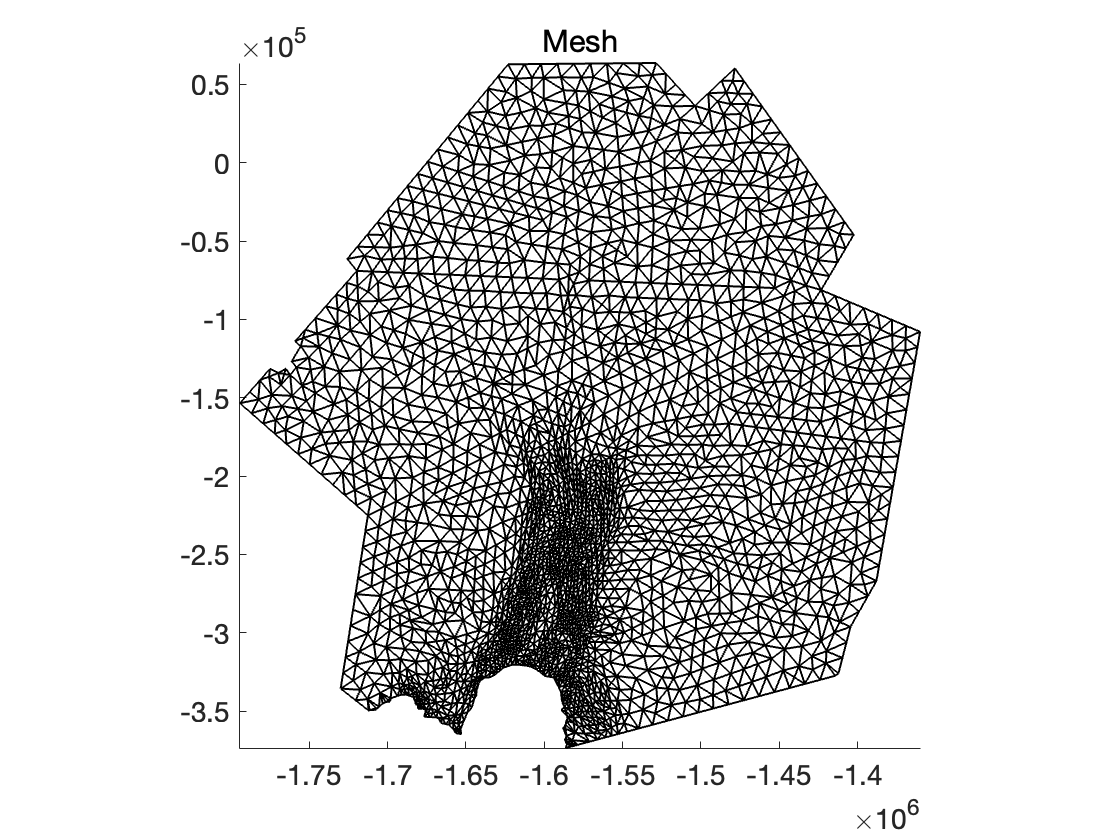

In [5]:
plotmodel(md, 'data', 'mesh');
save ./models/PIG_mesh md;

## Ice-Ocean Mask

In [6]:
md = loadmodel('./models/PIG_mesh');
searise = './data/Antarctica_5km_withshelves_v0.75.nc';

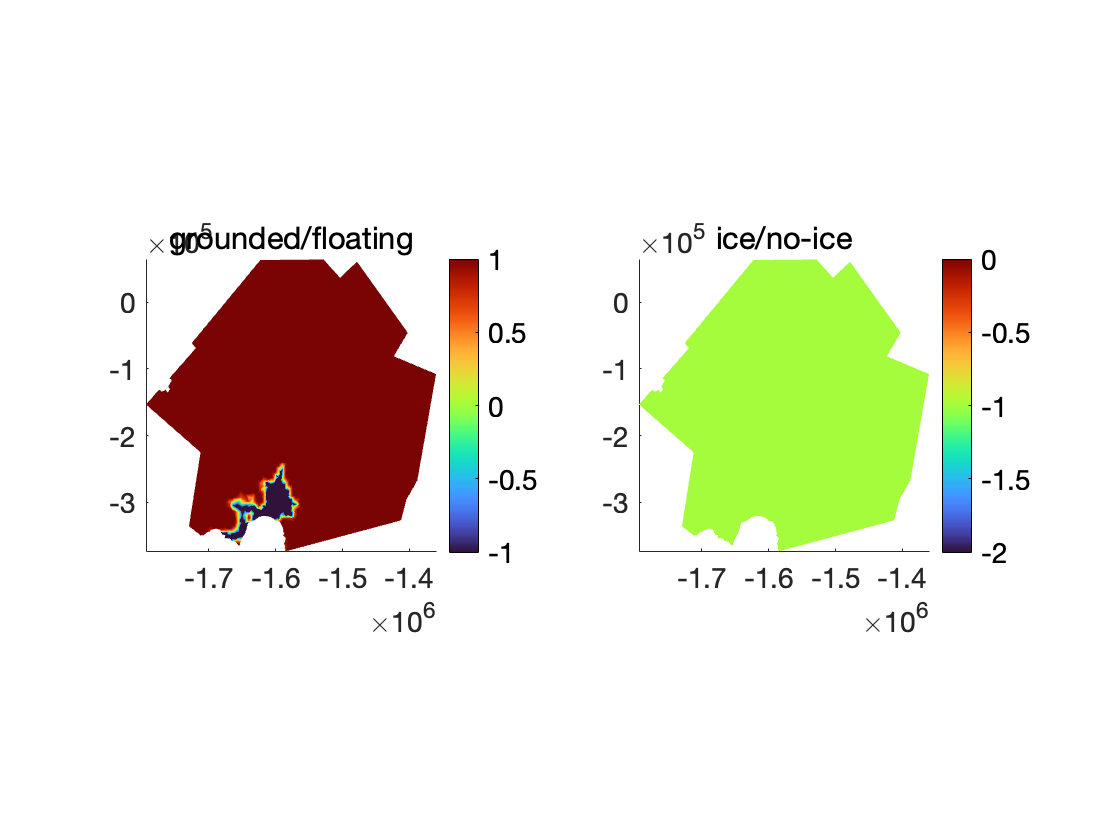

In [7]:
x1 = double(ncread(searise, 'x1'));
y1 = double(ncread(searise, 'y1'));
thkmask = double(ncread(searise, 'thkmask'));

groundedice = double(InterpFromGridToMesh(x1, y1, thkmask', md.mesh.x, md.mesh.y, 0));
groundedice(groundedice <= 0) =- 1;

md.mask.ocean_levelset = groundedice;
md.mask.ice_levelset =- 1 * ones(md.mesh.numberofvertices, 1);

plotmodel(md,'data',md.mask.ocean_levelset,'title','grounded/floating','data',md.mask.ice_levelset,'title','ice/no-ice');

save ./models/PIG_mask md;

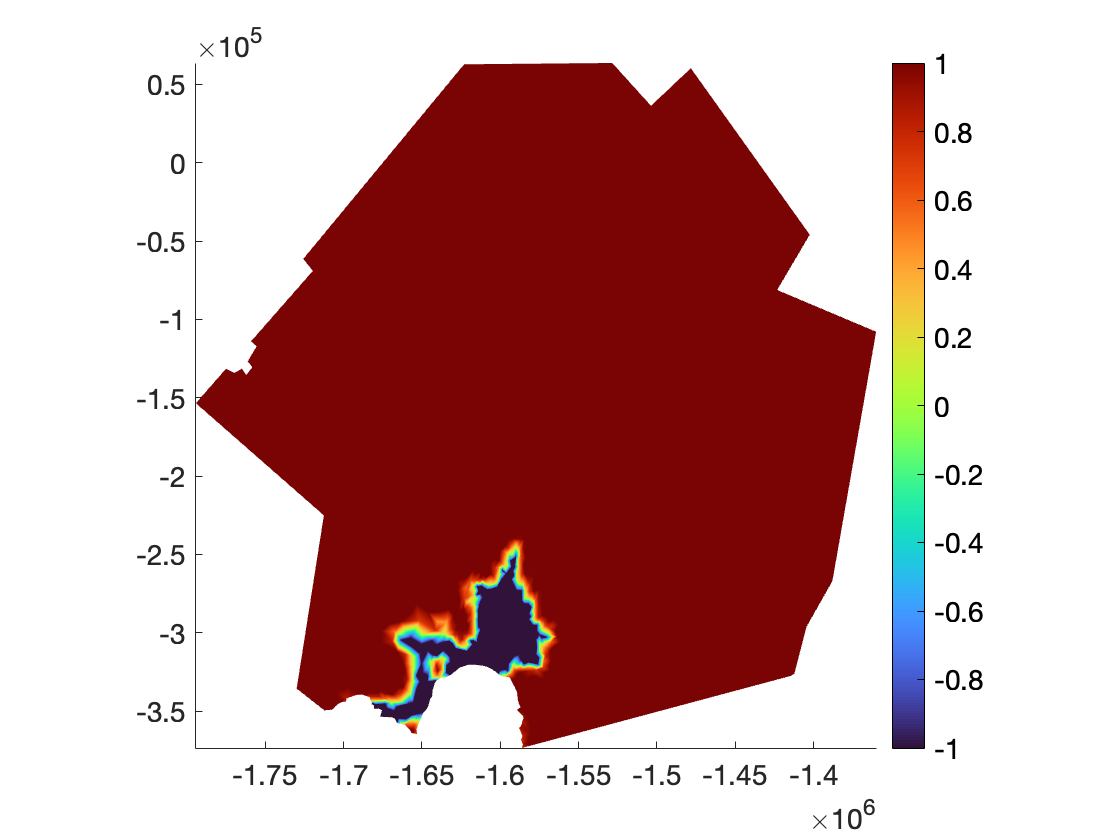

In [24]:
plotmodel(md, 'data', md.mask.ocean_levelset);

## Parameterization

In [8]:
md = loadmodel('./models/PIG_mask');
md = parameterize(md,'./data/Pig.par');
md = setflowequation(md,'SSA','all');
save ./models/PIG_param md;

   Loading SeaRISE data from NetCDF
   Interpolating surface and ice base
   Constructing thickness
   Interpolating temperatures
   Loading velocities data from NetCDF
   Set observed velocities
   Set Pressure
   Construct ice rheological properties
   Interpolating surface mass balance
   Set geothermal heat flux
   Construct basal friction parameters
   Set boundary conditions
      boundary conditions for stressbalance model: spc set as observed velocities
      no basalforcings.groundedice_melting_rate specified: values set as zero
      no basalforcings.floatingice_melting_rate specified: values set as zero
      no balancethickness.thickening_rate specified: values set as zero


## Inversion

In [9]:
md = loadmodel('./models/PIG_param');

md.inversion.iscontrol = 1;
md.inversion.maxsteps = 100;
md.inversion.maxiter = 100;
md.inversion.dxmin = 0.1;
md.inversion.gttol = 1.0e-4;
md.verbose = verbose('control', true);

md.inversion.cost_functions = [101 103 501];
md.inversion.cost_functions_coefficients = ones(md.mesh.numberofvertices, 3);
md.inversion.cost_functions_coefficients(:, 1) = 1;
md.inversion.cost_functions_coefficients(:, 2) = 2e-2;
md.inversion.cost_functions_coefficients(:, 3) = 1e-6;

md.inversion.control_parameters = {'FrictionCoefficient'};
md.inversion.min_parameters = 1 * ones(md.mesh.numberofvertices, 1);
md.inversion.max_parameters = 200 * ones(md.mesh.numberofvertices, 1);

md.stressbalance.restol = 0.01;
md.stressbalance.reltol = 0.01;
md.stressbalance.abstol = NaN;

md.toolkits = toolkits;
md.cluster = generic('name', oshostname, 'np', 10);

In [10]:
md = solve(md, 'Stressbalance');

launching solution sequence

Ice-sheet and Sea-level System Model (ISSM) version  4.24
(website: http://issm.jpl.nasa.gov forum: https://issm.ess.uci.edu/forum/)

call computational core:
   Initialize M1QN3 parameters
   Computing initial solution

┌────┬─────────────────┬────────────┬──────────────────────────────┐
│Iter│  Cost function  │ Grad. norm │  List of contributions       │
├────┼─────────────────┼────────────┼──────────────────────────────┤
│  1 │ f(x)=    1704.5 │       16.3 │      1479     225.6   0.00599│
│  2 │ f(x)=    449.93 │       1.73 │     249.3     200.6   0.01752│
│  3 │ f(x)=    400.92 │       1.39 │     207.1     193.8   0.01914│
│  4 │ f(x)=    270.85 │      0.661 │     103.6     167.2   0.02979│
│  5 │ f(x)=    205.67 │      0.386 │     58.73     146.9   0.04538│
│  6 │ f(x)=    152.57 │      0.211 │     29.29     123.2    0.0773│
│  7 │ f(x)=    115.79 │      0.121 │     14.42     101.2    0.1325│
│  8 │ f(x)=    86.743 │     0.0685 │     6.854     79.65   

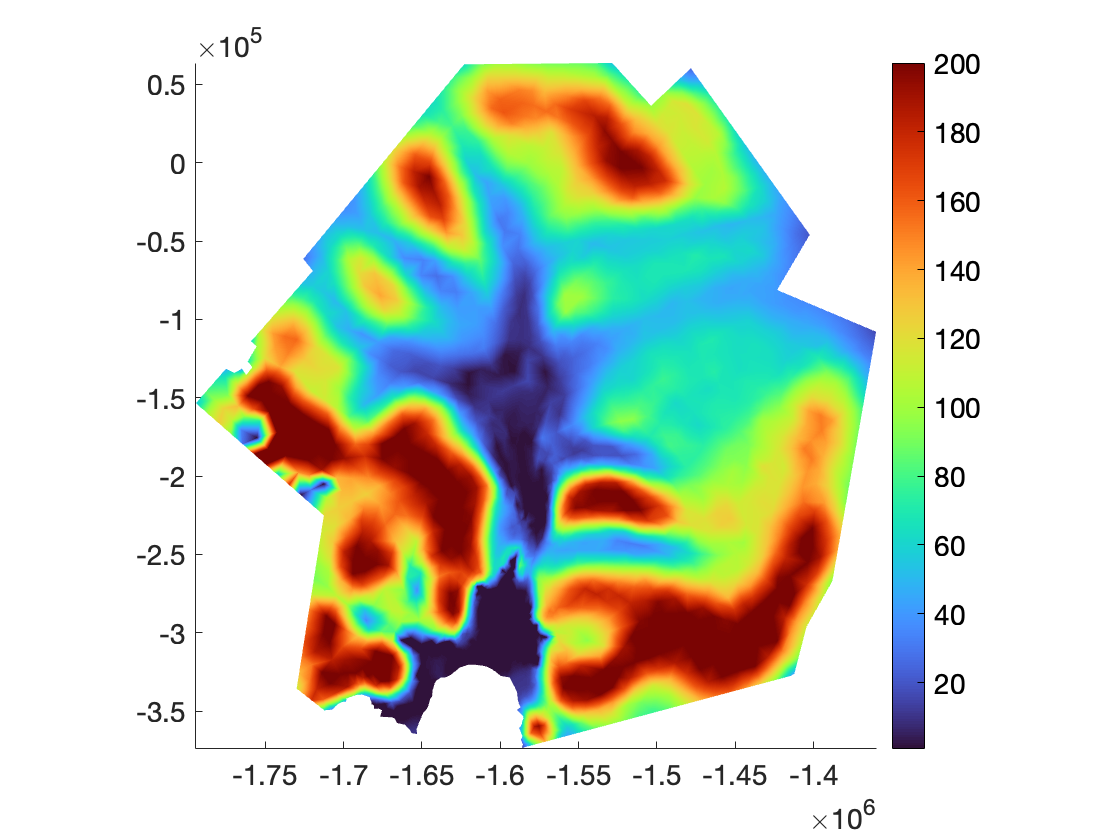

In [11]:
md.friction.coefficient = md.results.StressbalanceSolution.FrictionCoefficient;

plotmodel(md, 'data', md.friction.coefficient)

save ./models/PIG_control_drag md;

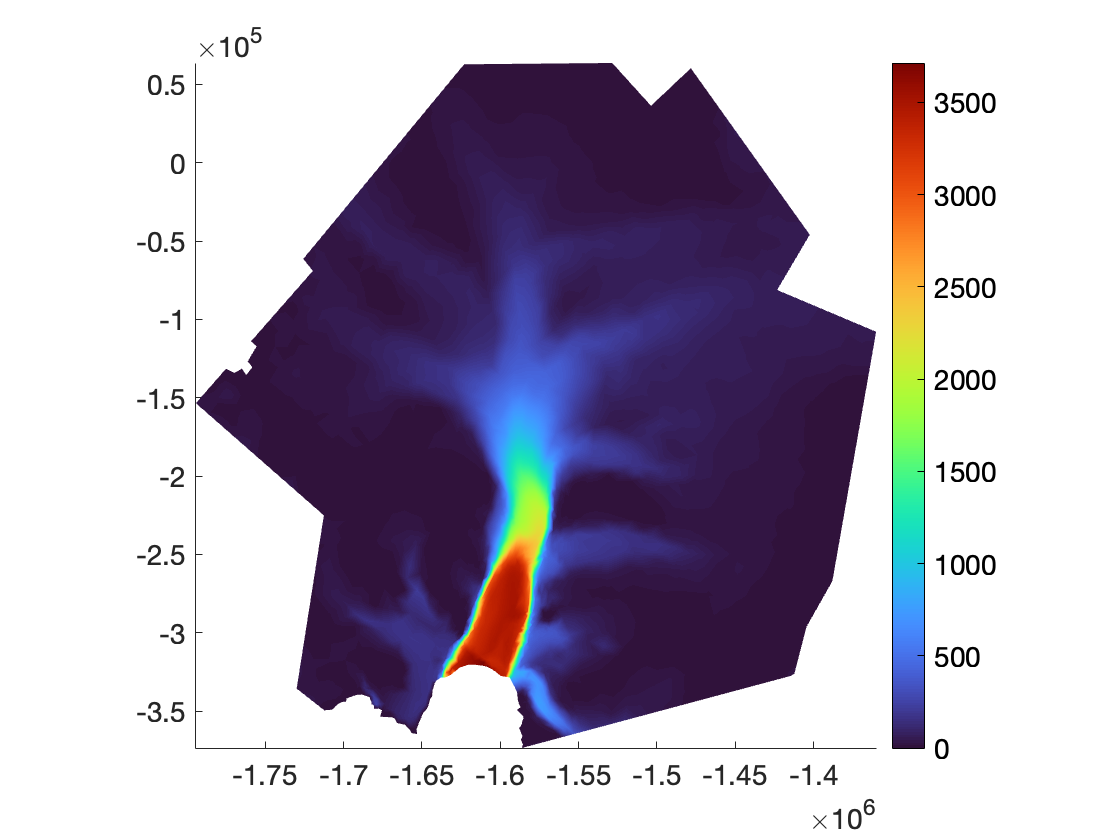

In [23]:
vel = sqrt(md.initialization.vx.^2 + md.initialization.vy.^2);
plotmodel(md, 'data', vel);